In [1]:
!pip install tensorflow pandas matplotlib scikit-learn -q

In [2]:
import tensorflow as tf
import pandas as pd

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=10000)

word_index = tf.keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode(text):
    return " ".join(reverse_word_index.get(i, "?") for i in text)

In [3]:
df = pd.DataFrame({
    "review_text": [decode(x) for x in train_data[:10000]],
    "label": train_labels[:10000]
})

df.head()

,review_text,label
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the <UNK> <UNK> at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [5]:
VOCAB_SIZE = 10000

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=200
)

vectorizer.adapt(X_train)

In [6]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train.values, y_train.values)
).batch(64)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test.values, y_test.values)
).batch(64)

train_ds = train_ds.map(
    lambda x, y: (vectorizer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (vectorizer(x), y)
)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        VOCAB_SIZE,
        32
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - binary_accuracy: 0.6195 - loss: 0.6772 - val_binary_accuracy: 0.7220 - val_loss: 0.6411
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - binary_accuracy: 0.7697 - loss: 0.5599 - val_binary_accuracy: 0.8145 - val_loss: 0.4885
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.8441 - loss: 0.4054 - val_binary_accuracy: 0.8240 - val_loss: 0.4108
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.8844 - loss: 0.3128 - val_binary_accuracy: 0.8395 - val_loss: 0.3728
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9111 - loss: 0.2546 - val_binary_accuracy: 0.8465 - val_loss: 0.3563


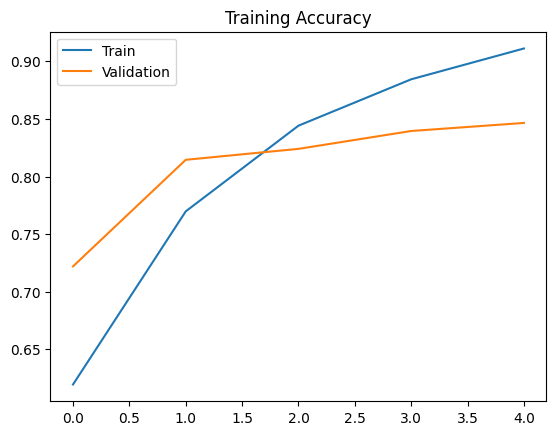

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["binary_accuracy"])
plt.plot(history.history["val_binary_accuracy"])

plt.legend(["Train","Validation"])
plt.title("Training Accuracy")
plt.show()

In [10]:
loss, accuracy = model.evaluate(test_ds)

print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8465 - loss: 0.3563
Accuracy: 0.8464999794960022


In [11]:
review = [
    "The product arrived broken and I am very unhappy"
]

prediction = model.predict(
    vectorizer(
        tf.constant(review)
    ),
    verbose=0
)

score = prediction[0][0]

print("Confidence Score:", score)

if score > 0.5:
    print("Positive")
else:
    print("Negative")

Confidence Score: 0.29023153
Negative


In [12]:
print(df.columns)

Index(['review_text', 'label'], dtype='object')
